In [1]:
import cv2
import os
import matplotlib.pyplot as plt
from PIL import Image,ImageChops
import random
from typing import List
import numpy as np
import glob
from tqdm import tqdm

In [2]:
os.chdir("../../Daten")

In [3]:
def is_greyscale(im):
    """
    Check if image is monochrome (1 channel or 3 identical channels)

    From Stackoverflow: https://stackoverflow.com/questions/23660929/how-to-check-whether-a-jpeg-image-is-color-or-gray-scale-using-only-python-stdli
    """
    if im.mode not in ("L", "RGB"):
        raise ValueError("Unsuported image mode")

    if im.mode == "RGB":
        rgb = im.split()
        if ImageChops.difference(rgb[0],rgb[1]).getextrema()[1]!=0: 
            return False
        if ImageChops.difference(rgb[0],rgb[2]).getextrema()[1]!=0: 
            return False
    return True


In [4]:
example_images_path = "./Sample1/Video/220615-152743-STtoST_3_6_10"

In [5]:
example_images_num_clean = [1, 150, 158, 165]
example_images_num_overexposed = [132, 135, 144]
example_images_num_underexposed = [171, 187]


In [6]:
im = Image.open(f"{example_images_path}/{str(random.choice(example_images_num_clean)).zfill(3)}.jpg")

In [7]:
is_greyscale(im)

False

## Images appear to not be exactly greyscale

In [8]:
def show_histograms(path: str, image_nums: List[int]):
    """
    From: https://stackoverflow.com/questions/22159160/python-calculate-histogram-of-image
    """
    fig, axes = plt.subplots(1,len(image_nums))
    fig.set_size_inches(15,5)
    for image_num, ax in zip(image_nums, axes):
        image_path = f"{path}/{str(image_num).zfill(3)}.jpg"
        im = cv2.imread(image_path)
        # calculate mean value from RGB channels and flatten to 1D array
        vals = im.mean(axis=2).flatten()
        # plot histogram with 255 bins
        b, bins, patches = ax.hist(vals, 255)
        ax.set_xlim([0,255])

    plt.show()

# Let's look at the histogram of 'clean' images

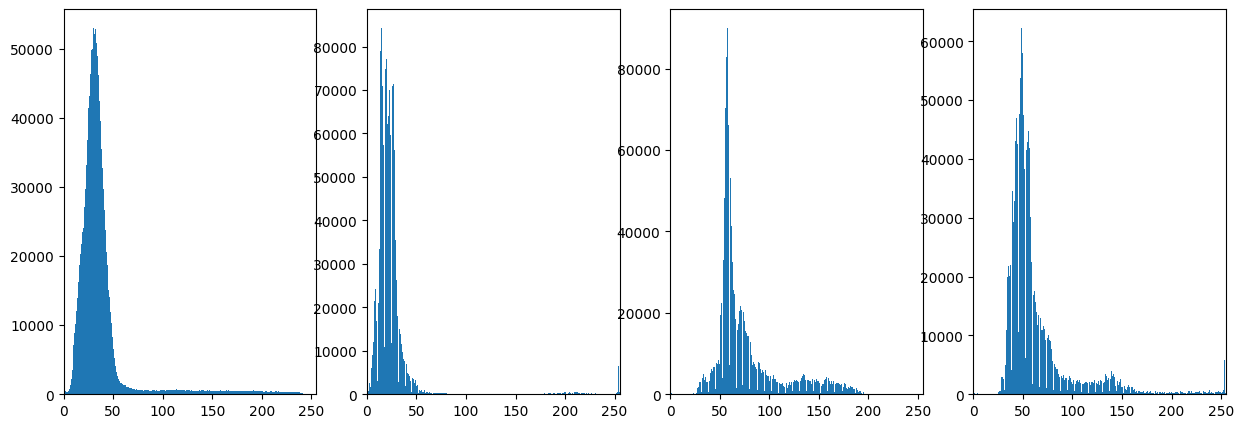

In [9]:
show_histograms(example_images_path, example_images_num_clean)

# Let's look at the histogram of overexposed images

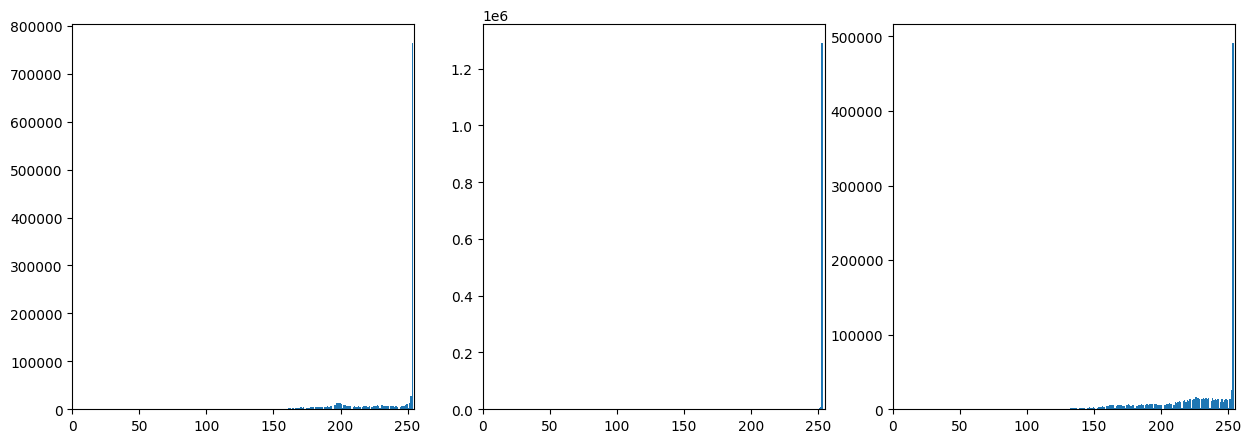

In [10]:
show_histograms(example_images_path, example_images_num_overexposed)

# Let's look at the histogram of underexposed images

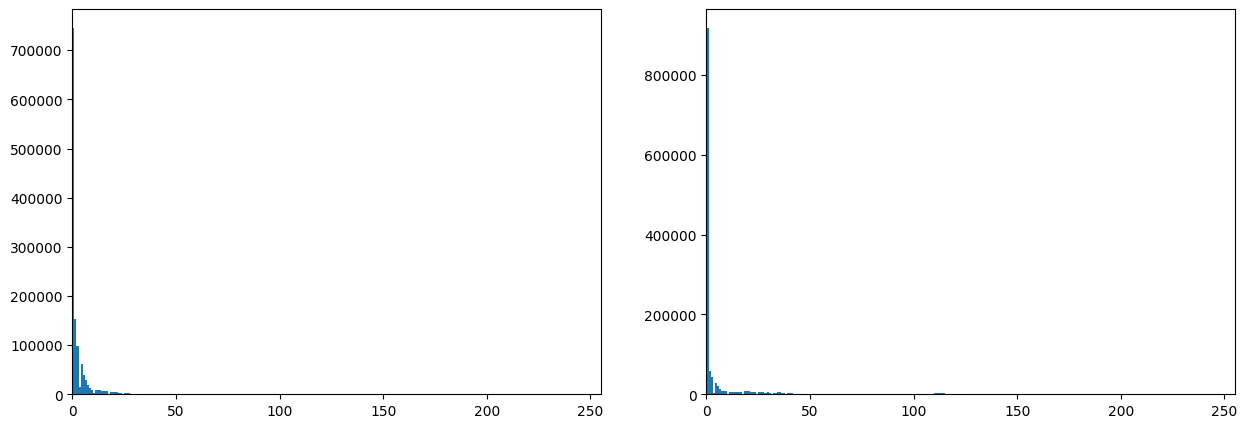

In [11]:
show_histograms(example_images_path, example_images_num_underexposed)

In [12]:
def is_overexposed(image_path: str, bins: int = 5):
    """
    We take a look at the histogram of the flattened picture (which is converted to greyscale first by taking the mean across the three color channels).
    Only if the last bin contains the largest number of pixels, we define the image to be overexposed.
    """
    im = cv2.imread(image_path)
    vals = im.mean(axis=2)
    return np.argmax(np.histogram(vals, bins=bins)[0]) == bins - 1

In [13]:
def is_underexposed(image_path: str, bins: int = 5):
    """
    We do not classfiy any images as underexposed as of now.
    """
    return False

In [14]:
for image_num in example_images_num_overexposed:
    image_path = f"{example_images_path}/{str(image_num).zfill(3)}.jpg"
    print(is_overexposed(image_path))

True
True
True


In [ ]:
removed_counter = 0

frames_dir = "./extracted_frames_no_duplicates/"
removed_frames_dir = "./removed_frames/"

for frame_name in tqdm(glob.iglob(f"{frames_dir}*.jpg")):
    if is_overexposed(frame_name) or is_underexposed(frame_name):
        os.rename(frame_name, f"{removed_frames_dir}{frame_name.lstrip(frames_dir)}")
        removed_counter += 1

print(f"Number of frames that have been removed from the data: {removed_counter}")